# Data Preparation and EDA

In [31]:
# packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 1. Load & clean survey

### 1.1 Understand structure and types first 

In [ ]:
# Load and inspect survey data
survey = pd.read_csv('data/data_original/survey.csv')
print(survey.head(2))

   Member ID  Age Member Gender Prospective Risk Concurrent Risk  \
0          1   84             F            23.72           13.39   
1          2   62             F             1.76            0.75   

   # of Chronic Conditions ADHD Asthma Blood Disorders Cancer  ...  \
0                        7   No     No              No    Yes  ...   
1                        4   No     No              No     No  ...   

  Chronic Respiratory Failure Depression Diabetes ESRD Eating Disorders  \
0                          No        Yes      Yes   No               No   
1                          No         No       No   No               No   

  HIV/AIDS Hyperlipidemia Hypertension Lower Back Pain  \
0       No            Yes          Yes              No   
1       No             No          Yes             Yes   

                             Patient Survey Response  
0                                                NaN  
1  I don't feel like my doctor listens to my conc...  

[2 rows x 22 colu

> data loaded properly

In [3]:
# Basic shape and preview
print(survey.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4783 entries, 0 to 4782
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Member ID                    4783 non-null   int64 
 1   Age                          4783 non-null   int64 
 2   Member Gender                4783 non-null   object
 3   Prospective Risk             4783 non-null   object
 4   Concurrent Risk              4783 non-null   object
 5   # of Chronic Conditions      4783 non-null   int64 
 6   ADHD                         4783 non-null   object
 7   Asthma                       4783 non-null   object
 8   Blood Disorders              4783 non-null   object
 9   Cancer                       4783 non-null   object
 10  Chronic Pain                 4783 non-null   object
 11  Congestive Heart Failure     4783 non-null   object
 12  Chronic Respiratory Failure  4783 non-null   object
 13  Depression                   4783

> info looks good
> some missing value of column 21
> numerical and categorical columns need to be converted properly

### 1.2 Convert data types

data conversion before handling missing data, duplication, or placeholders because they would not show properly without the proper type of format.

#### 1.2.1 convert numeric columns

Prospective Risk    float64
Concurrent Risk     float64
dtype: object
       Prospective Risk  Concurrent Risk
count       4421.000000      4421.000000
mean           1.442904         1.418831
std            2.618634         2.925282
min            0.070000         0.000000
25%            0.330000         0.080000
50%            0.720000         0.530000
75%            1.660000         1.550000
max           55.980000        60.780000


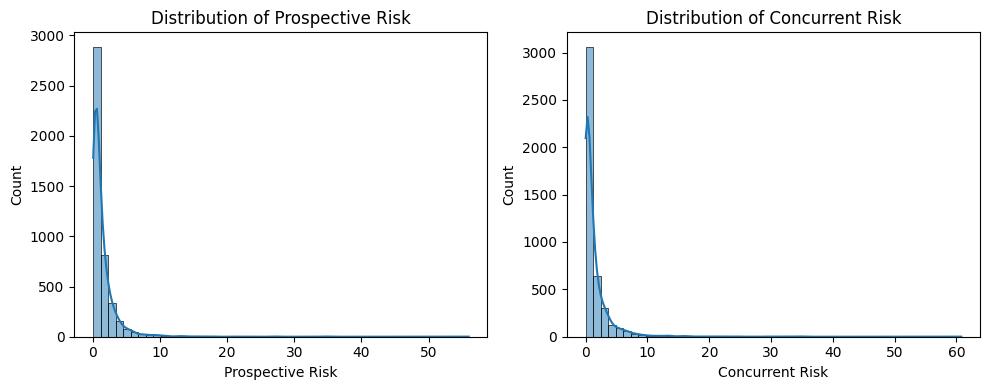

In [5]:
# Convert risk scores to numeric
survey_clean = survey.copy()

risk_cols = ["Prospective Risk", "Concurrent Risk"]

for col in risk_cols:
    survey_clean[col] = pd.to_numeric(survey_clean[col], errors="coerce")

print(survey_clean[risk_cols].dtypes)
print(survey_clean[risk_cols].describe())

# Histograms to see distributions
plt.figure(figsize=(10, 4))

for i, col in enumerate(risk_cols, 1):
    plt.subplot(1, 2, i)
    sns.histplot(survey_clean[col], kde=True, bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

> Risk distributions are extremely right‑skewed with a long tail and a few very high values (up to ~56 and ~61), which are likely true high‑risk members but will behave as outliers statistically.
> Do log transformation and check the distribution again.

#### 1.2.2 convert categorial columns

I keep the some of the categorical columns with numeric fillings for the ease of modeling and feature engineering

ADHD                           int64
Asthma                         int64
Blood Disorders                int64
Cancer                         int64
Chronic Pain                   int64
Congestive Heart Failure       int64
Chronic Respiratory Failure    int64
Depression                     int64
Diabetes                       int64
ESRD                           int64
Eating Disorders               int64
HIV/AIDS                       int64
Hyperlipidemia                 int64
Hypertension                   int64
Lower Back Pain                int64
dtype: object
NaNs per condition:
 ADHD                           0
Asthma                         0
Blood Disorders                0
Cancer                         0
Chronic Pain                   0
Congestive Heart Failure       0
Chronic Respiratory Failure    0
Depression                     0
Diabetes                       0
ESRD                           0
Eating Disorders               0
HIV/AIDS                       0
Hyperlipidemia

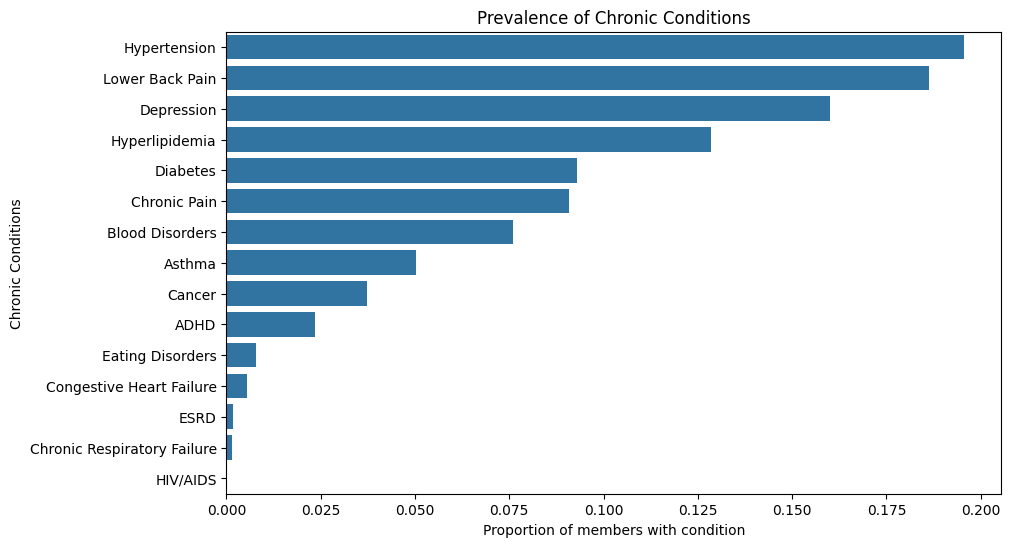

In [6]:
# Binary flags to 0/1
condition_cols = [
    "ADHD", "Asthma", "Blood Disorders", "Cancer", "Chronic Pain",
    "Congestive Heart Failure", "Chronic Respiratory Failure", "Depression",
    "Diabetes", "ESRD", "Eating Disorders", "HIV/AIDS", "Hyperlipidemia",
    "Hypertension", "Lower Back Pain"
]

yes_no_map = {"Yes": 1, "No": 0}

for col in condition_cols:
    survey_clean[col] = survey_clean[col].map(yes_no_map)

print(survey_clean[condition_cols].dtypes)
print("NaNs per condition:\n", survey_clean[condition_cols].isna().sum())

# Barplot of prevalence for each condition
condition_prevalence = survey_clean[condition_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=condition_prevalence.values, y=condition_prevalence.index, orient="h")
plt.xlabel("Proportion of members with condition")
plt.ylabel("Chronic Conditions")
plt.title("Prevalence of Chronic Conditions")
plt.show()

> Conditions are nicely encoded as 0/1 ints with no missing values; prevalence plot shows hypertension, lower back pain, depression, hyperlipidemia, and diabetes as the most common, which is clinically plausible.

In [7]:
survey['Member Gender'].value_counts()

Member Gender
M    2628
F    2155
Name: count, dtype: int64

#### 1.2.3 Convert pure categorical column

Member Gender
M    2628
F    2155
Name: count, dtype: int64


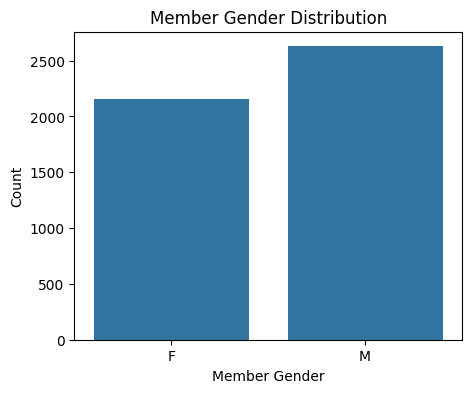

In [8]:
# Clean gender and cast to category
survey_clean["Member Gender"] = survey_clean["Member Gender"].str.strip()

gender_map = {
    "M": "M",
    "F": "F"
}

survey_clean["Member Gender"] = survey_clean["Member Gender"].replace(gender_map)
survey_clean["Member Gender"] = survey_clean["Member Gender"].astype("category")

print(survey_clean["Member Gender"].value_counts(dropna=False))

# Visualization: gender distribution
plt.figure(figsize=(5, 4))
sns.countplot(x=survey_clean["Member Gender"])
plt.title("Member Gender Distribution")
plt.ylabel("Count")
plt.show()

> Gender is a simple M/F split with slightly more males; Member Gender is now a categorical type, which is perfect. However, spectrum is not covered

In [9]:
survey_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4783 entries, 0 to 4782
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Member ID                    4783 non-null   int64   
 1   Age                          4783 non-null   int64   
 2   Member Gender                4783 non-null   category
 3   Prospective Risk             4421 non-null   float64 
 4   Concurrent Risk              4421 non-null   float64 
 5   # of Chronic Conditions      4783 non-null   int64   
 6   ADHD                         4783 non-null   int64   
 7   Asthma                       4783 non-null   int64   
 8   Blood Disorders              4783 non-null   int64   
 9   Cancer                       4783 non-null   int64   
 10  Chronic Pain                 4783 non-null   int64   
 11  Congestive Heart Failure     4783 non-null   int64   
 12  Chronic Respiratory Failure  4783 non-null   int64   
 13  Dep

> only two columns have missing (Prospective Risk, Concurrent Risk), plus the free‑text survey responses, which is expected.

### 1.3 Detection and handling missing values, duplications, and outliers

#### 1.3.1 missing values

In [11]:
import missingno as msno

In [16]:
# Quick numeric summary of missingness
print(survey_clean.isna().sum())
print(survey_clean.isna().sum() / len(survey_clean))

Member ID                        0
Age                              0
Member Gender                    0
Prospective Risk               362
Concurrent Risk                362
# of Chronic Conditions          0
ADHD                             0
Asthma                           0
Blood Disorders                  0
Cancer                           0
Chronic Pain                     0
Congestive Heart Failure         0
Chronic Respiratory Failure      0
Depression                       0
Diabetes                         0
ESRD                             0
Eating Disorders                 0
HIV/AIDS                         0
Hyperlipidemia                   0
Hypertension                     0
Lower Back Pain                  0
Patient Survey Response        717
dtype: int64
Member ID                      0.000000
Age                            0.000000
Member Gender                  0.000000
Prospective Risk               0.075685
Concurrent Risk                0.075685
# of Chronic Cond

> No missing values except for the following 3 columns:
> Prospective Risk：362, taking 7.5685%
> Concurrent Risk：362, taking 7.5685%
> Patient Survey Response：717, taking 15%
> Quantity and proportion are both small. We can keep the columns and rows but leave the risk values as NaN for now; many models can handle missing numeric features, and we might choose simple imputation later (e.g., median) if needed.

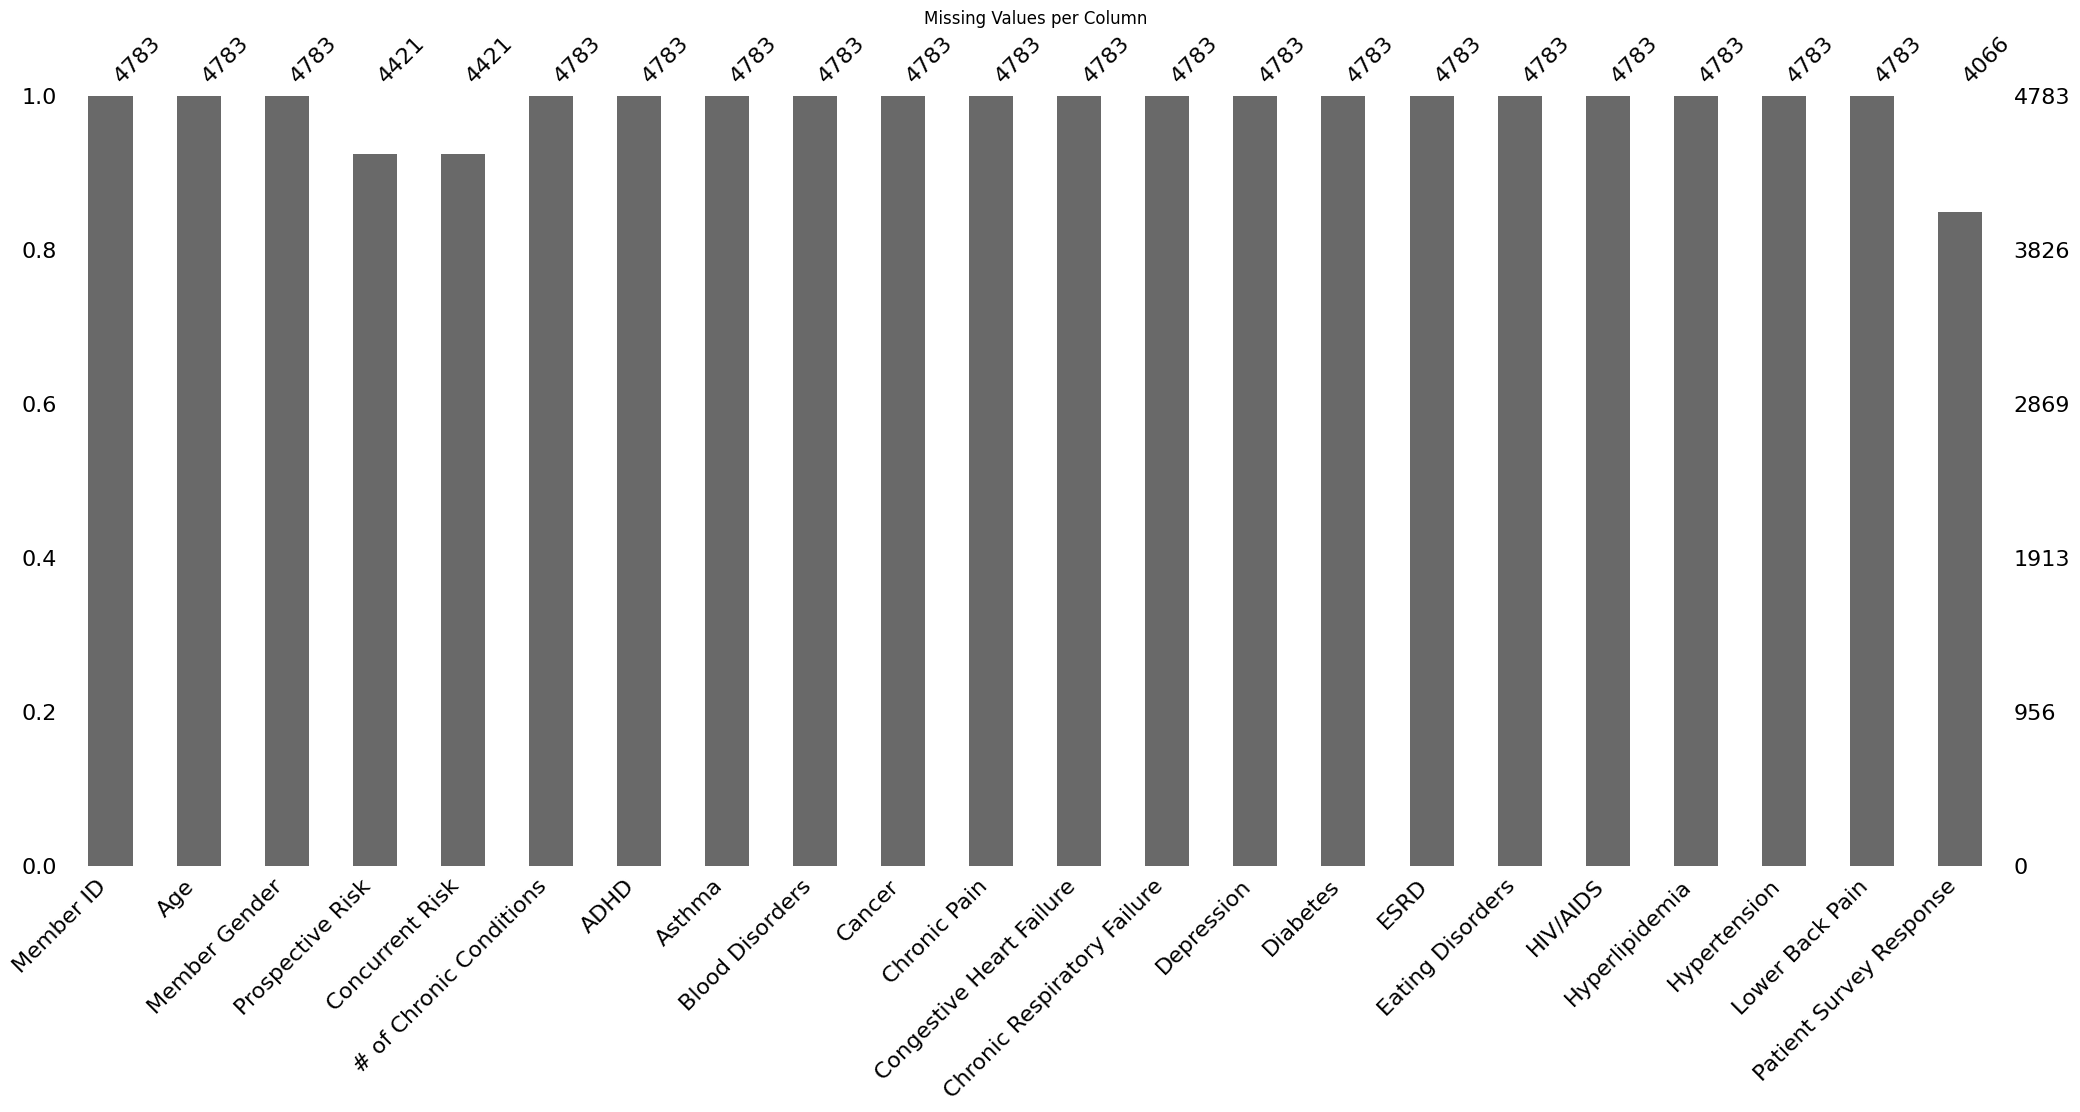

<Figure size 500x400 with 0 Axes>

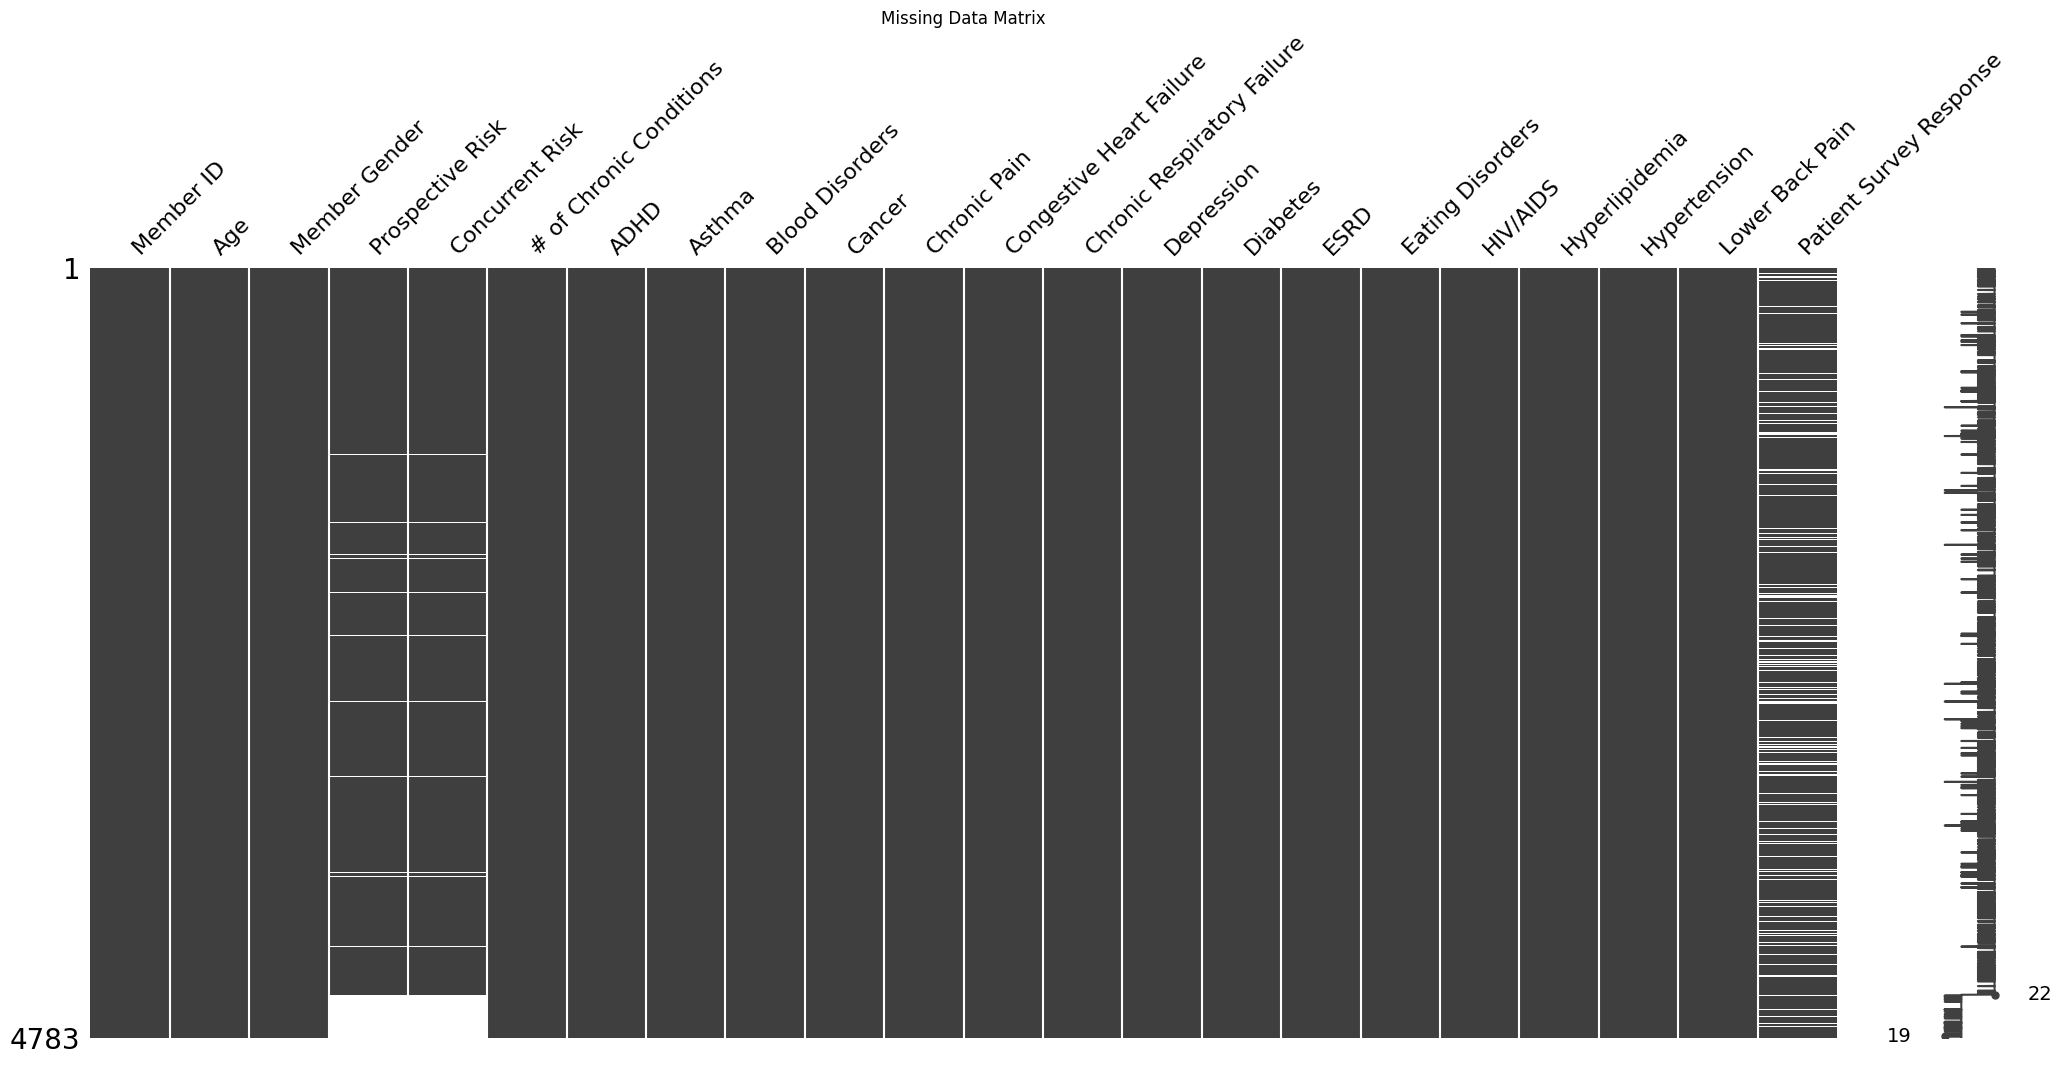

<Figure size 400x300 with 0 Axes>

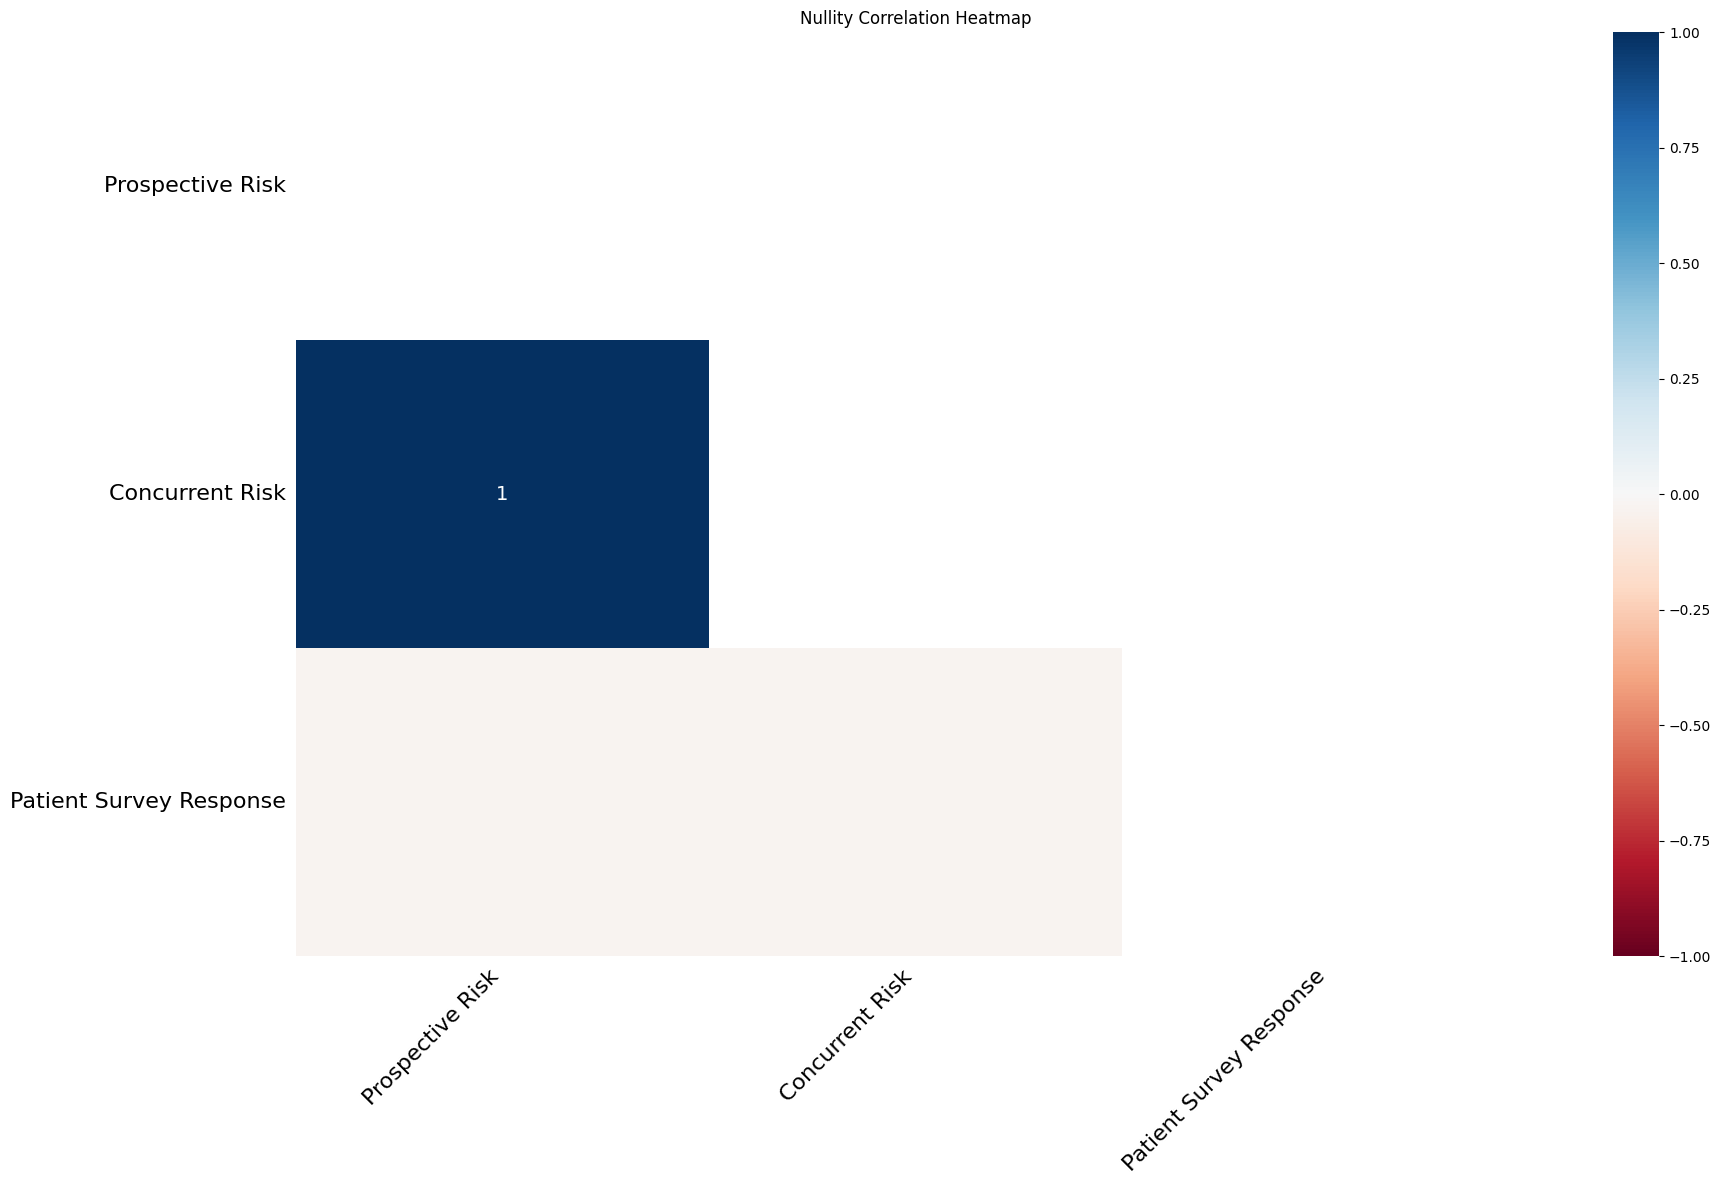

In [15]:
# 2) Bar chart of missingness per column
plt.figure(figsize=(5, 4))
msno.bar(survey_clean)
plt.title("Missing Values per Column")
plt.show()

# 3) Matrix plot to see patterns along rows
plt.figure(figsize=(5, 4))
msno.matrix(survey_clean)
plt.title("Missing Data Matrix")
plt.show()

# 4) (Optional) Heatmap of nullity correlations
plt.figure(figsize=(4, 3))
msno.heatmap(survey_clean)
plt.title("Nullity Correlation Heatmap")
plt.show()

> Missing values of Prospective Risk and Concurrent Risk are highly correlated.
> Missing values of Patient survey response is random, which is expected.

#### 1.3.2 Duplication

Strategies
- Exact duplicate rows (same member, same risks, same conditions, same response).
- Multiple survey responses from the same member (duplicate Member ID with potentially different responses).

In [17]:
# 1) Exact duplicate rows
exact_dups = survey_clean.duplicated()
print("Number of completely duplicated rows:", exact_dups.sum())

# Optionally, see a few examples if any
if exact_dups.sum() > 0:
    display(survey_clean[exact_dups].head())

# 2) Duplicate Member IDs
id_counts = survey_clean["Member ID"].value_counts()
multi_response_ids = id_counts[id_counts > 1]

print("Number of members with >1 survey record:", multi_response_ids.shape[0])
print("Top few counts:\n", multi_response_ids.head())

# 3) Quick look at one such member (if any)
if multi_response_ids.shape[0] > 0:
    sample_id = multi_response_ids.index[0]
    print("Example records for Member ID:", sample_id)
    display(survey_clean[survey_clean["Member ID"] == sample_id])

Number of completely duplicated rows: 0
Number of members with >1 survey record: 0
Top few counts:
 Series([], Name: count, dtype: int64)


> No duplication found from simple glimpse

#### 1.3.3 Outliers

detect outliers first and then decide what to do case by case
Due to the content of this dataset, we could only detect outliers for certain columns

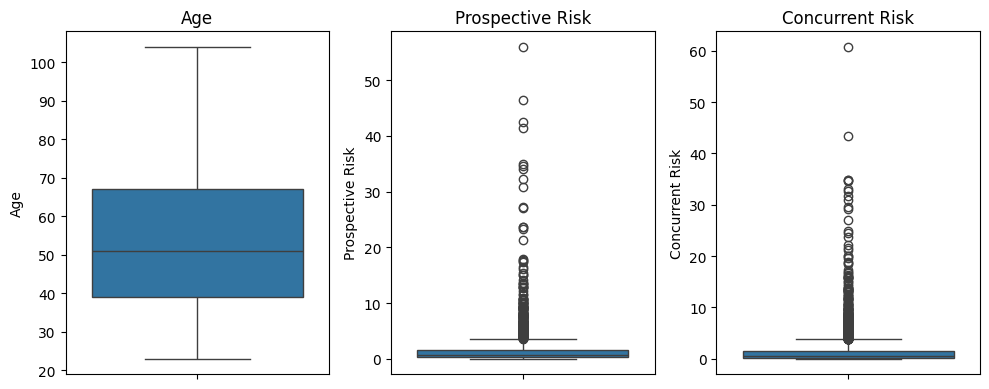

In [18]:
# 1) Boxplots for age and risk
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
sns.boxplot(y=survey_clean["Age"])
plt.title("Age")

plt.subplot(1, 3, 2)
sns.boxplot(y=survey_clean["Prospective Risk"])
plt.title("Prospective Risk")

plt.subplot(1, 3, 3)
sns.boxplot(y=survey_clean["Concurrent Risk"])
plt.title("Concurrent Risk")

plt.tight_layout()
plt.show()

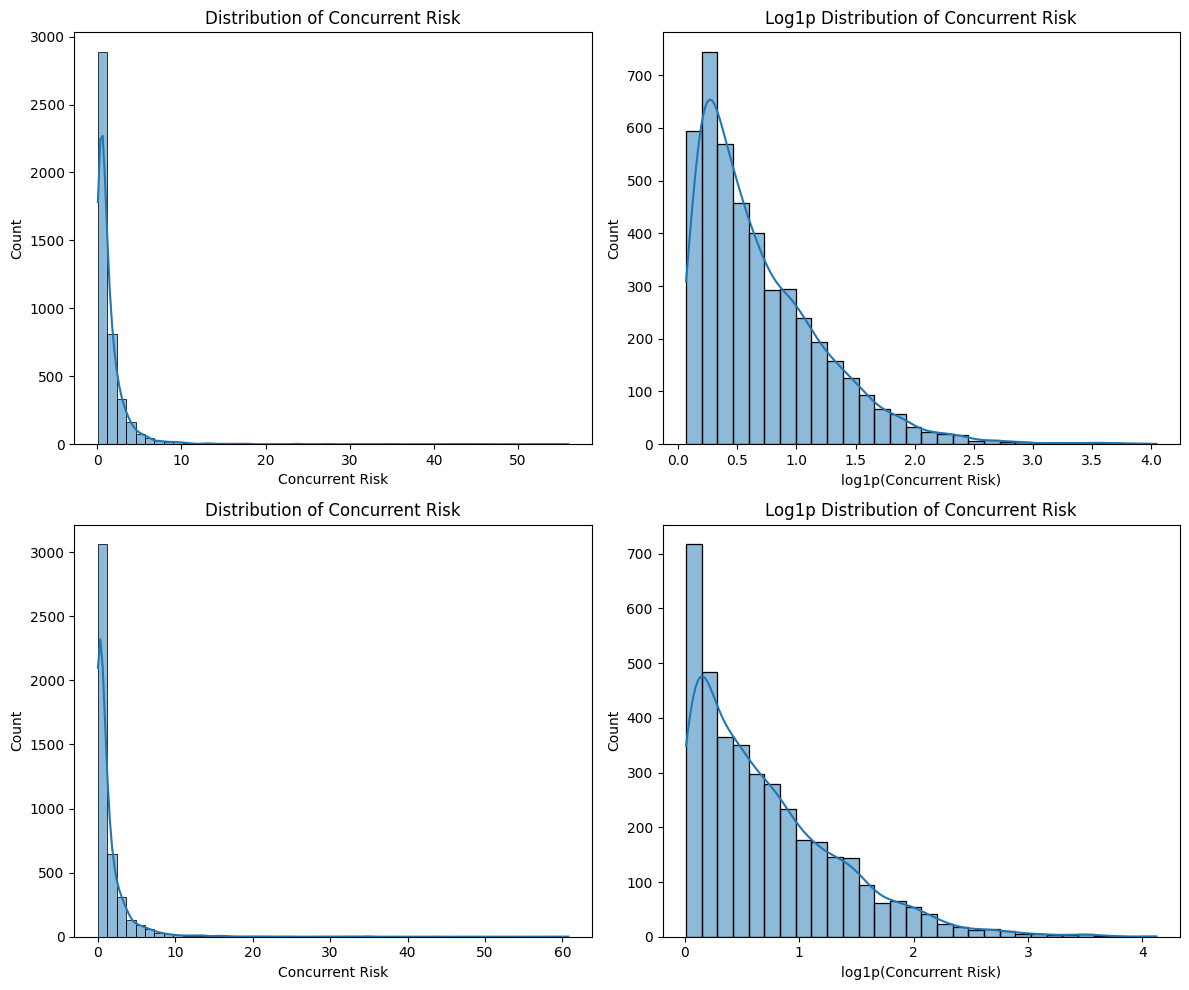

In [22]:
# 2) Log-transformed histograms for risk scores (to see tail better)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# plots 1 original prospective risk, 
ax1 = axes[0, 0]
sns.histplot(survey_clean['Prospective Risk'], kde=True, bins=50, ax=ax1)
ax1.set_title(f"Distribution of {col}")
ax1.set_xlabel(col)
# plots 2 log prospective risk, 
ax2 = axes[0, 1]
positive = survey_clean['Prospective Risk'][survey_clean['Prospective Risk'] > 0]
sns.histplot(np.log1p(positive), bins=30, kde=True, ax=ax2)
ax2.set_title(f"Log1p Distribution of {col}")
ax2.set_xlabel(f"log1p({col})")
# plots 3 original concurrent risk,
ax3 = axes[1, 0]
sns.histplot(survey_clean['Concurrent Risk'], kde=True, bins=50, ax=ax3)
ax3.set_title(f"Distribution of {col}")
ax3.set_xlabel(col)
# plots 4 log concurrent risk
ax4 = axes[1, 1]
positive = survey_clean['Concurrent Risk'][survey_clean['Concurrent Risk'] > 0]
sns.histplot(np.log1p(positive), bins=30, kde=True, ax=ax4)
ax4.set_title(f"Log1p Distribution of {col}")
ax4.set_xlabel(f"log1p({col})")
# show all
plt.tight_layout()
plt.show()

> For Method: The log1p transform you plotted is exactly the standard way to handle such right‑skewed, strictly positive features: it reduces skew and makes variance more stable, which helps many models and linear relationships.

> For observation: the plots show both risks are heavily right‑skewed in the raw scale, and the log1p transform gives a much more spread-out, almost exponential-looking distribution. That suggests there are high‑risk outliers but they look like a long tail rather than obvious data entry errors, so for now they’re probably fine to keep and maybe log-transform later for modeling.


> For conclusion: we keep the high risk scores as legitimate values, not errors, so we do not drop them as outliers.

### 1.4 Save clean dataset

In [24]:
# Save cleaned survey data
survey_clean.to_csv("data/survey_clean.csv", index=False)

## 2. Load & clean claims

### 2.1 Understand structure and types first

In [26]:
# You may need low_memory=False depending on the file
claims = pd.read_csv('data/data_original/claims.csv', low_memory=False)
claims.head(2)

,Member ID,Claim Number,Service Date,Paid Date,Place of Service Description,Speciality,Provider Specialty,Paid Amount,Allowed Amount,Primary Diagnosis Desc,Procedure Description,CPT4,Vendor Name,Procedure,Procedure Grouper Desc,Procedure Sub-Grouper Desc,Diagnosis Grouper 1 Desc,Diagnosis Super-Grouper 1 Desc
0,1.0,H19343218281891900000000,11/13/19,12/13/19,Outpatient Hospital,A1,DWSC1-12,$159.38,$159.38,"Edema, Unspecified",Hydrate Iv Infusion Add-On,96361,Blue Cross,96361,Other Procedures,Minor Procedures - Other,Constitutional Symptoms,Miscellaneous
1,1.0,H19343218281891900000000,11/13/19,12/13/19,Outpatient Hospital,A1,DWSC1-12,$14.22,$14.22,"Edema, Unspecified",Routine Venipuncture,36415,Blue Cross,36415,Laboratory,Lab - Blood Tests,Constitutional Symptoms,Miscellaneous


In [27]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144247 entries, 0 to 144246
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Member ID                       144247 non-null  float64
 1   Claim Number                    144247 non-null  object 
 2   Service Date                    144247 non-null  object 
 3   Paid Date                       144247 non-null  object 
 4   Place of Service Description    144247 non-null  object 
 5   Speciality                      144247 non-null  object 
 6   Provider Specialty              144247 non-null  object 
 7   Paid Amount                     144247 non-null  object 
 8   Allowed Amount                  144247 non-null  object 
 9   Primary Diagnosis Desc          144247 non-null  object 
 10  Procedure Description           144247 non-null  object 
 11  CPT4                            144247 non-null  object 
 12  Vendor Name     

> Member ID is numeric but as float64 (probably should be integer / string ID).
> Monetary fields (Paid Amount, Allowed Amount) are object, so they’ll need cleaning and numeric conversion.
> Dates are also object and should become datetime types.
> No obvious missing values

### 2.2 Convert data types

here we only do numerical and datetime but skip categorical for the reasons that
- keeping them as string / object does not make any difference on EDA or basic stats
- encoding can be very helpful for modeling later
- some columns have huge cardinality (hundreds of distinct values), which can be used as text or not being selected for modeling eventually

In [33]:
claims_clean = claims.copy()

#### 2.2.1 Convert numerical columns

In [34]:
# 1) Member ID: float -> int (if no missing) and then maybe category
claims_clean["Member ID"] = claims_clean["Member ID"].astype("int64")

In [35]:
# 3) Clean currency/amount columns (remove commas, $ signs, etc., then to float)
amount_cols = ["Paid Amount", "Allowed Amount"]

for col in amount_cols:
    # Strip currency symbols and commas
    claims_clean[col] = (
        claims_clean[col]
        .astype(str)
        .str.replace(r"[^0-9.\-]", "", regex=True)
    )
    claims_clean[col] = pd.to_numeric(claims_clean[col], errors="coerce")

#### 2.2.2 Convert Datetime

In [38]:
# Convert dates to datetime
date_cols = ["Service Date", "Paid Date"]
for col in date_cols:
    claims_clean[col] = pd.to_datetime(claims_clean[col], errors="coerce")

#### 2.2.3 check after conversion

In [39]:
claims_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144247 entries, 0 to 144246
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Member ID                       144247 non-null  int64         
 1   Claim Number                    144247 non-null  object        
 2   Service Date                    144247 non-null  datetime64[ns]
 3   Paid Date                       144247 non-null  datetime64[ns]
 4   Place of Service Description    144247 non-null  object        
 5   Speciality                      144247 non-null  object        
 6   Provider Specialty              144247 non-null  object        
 7   Paid Amount                     140301 non-null  float64       
 8   Allowed Amount                  134259 non-null  float64       
 9   Primary Diagnosis Desc          144247 non-null  object        
 10  Procedure Description           144247 non-null  object 

> After type conversion, we see placeholders used for paid and allowed amounts are shown as missing values now. We can handle this in the next step.

### 2.3 Detection and handling missing values, duplications, and outliers

#### 2.3.1 Missing values

In [42]:
# double check  missing values
claims_clean.isna().sum()

Member ID                            0
Claim Number                         0
Service Date                         0
Paid Date                            0
Place of Service Description         0
Speciality                           0
Provider Specialty                   0
Paid Amount                       3946
Allowed Amount                    9988
Primary Diagnosis Desc               0
Procedure Description                0
CPT4                                 0
Vendor Name                          0
Procedure                            0
Procedure Grouper Desc               0
Procedure Sub-Grouper Desc           0
Diagnosis Grouper 1 Desc             0
Diagnosis Super-Grouper 1 Desc       0
dtype: int64

In [45]:
claims_clean[["Paid Amount", "Allowed Amount"]].isna().mean()

Paid Amount       0.027356
Allowed Amount    0.069242
dtype: float64

> Paid Amount misses 3946 values, about 2.7%
> Allowed Amount misses 9988 values, about 6.9%
> The absolute count and percentage are low. 
> The reason for missing values is expected as it is normal for healthcare industry to have payments post services for quite a period.
> Due to the importance, reasonable excuses, and low missing, we should definitely keep the columns.

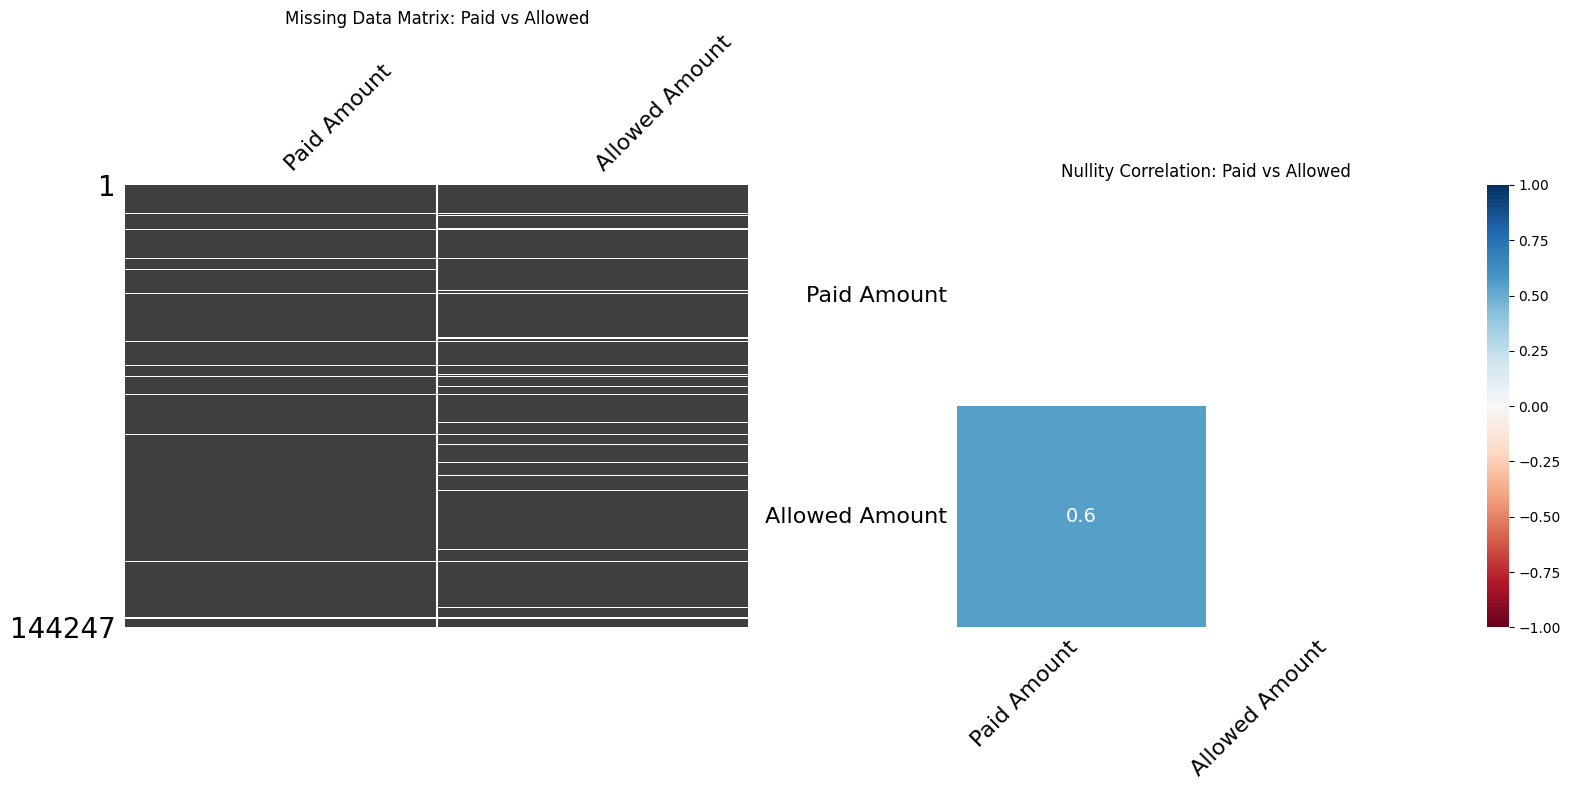

In [55]:
# Matrix to see row-wise pattern and correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
# Plot 1: Matrix to see row-wise pattern
ax1 = axes[0]
msno.matrix(claims_clean[["Paid Amount", "Allowed Amount"]], ax=ax1)
ax1.set_title("Missing Data Matrix: Paid vs Allowed")
# Plot 2: Heatmap for nullity correlation
ax2 = axes[1]
msno.heatmap(claims_clean[["Paid Amount", "Allowed Amount"]], ax=ax2)
ax2.set_title("Nullity Correlation: Paid vs Allowed")
# show all
plt.tight_layout()
plt.show()

> based on the fact that
> $allowed = insurance + paid$
>  we can infer that there is not much real correlation between the missing values of the two amounts. There might be the case where the insurance paid earlier than the patient did or vice versa. Some correlation might be because of time where neither has paid yet.

#### 2.3.2 Duplication

In [56]:
claims.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
144242    False
144243    False
144244    False
144245    False
144246    False
Length: 144247, dtype: bool

#### 2.3.3 Outliers

Due to the column nature, I am not going to find outliers for all. I will focus on paid and allowed amount. They both are expected to be heavily right skewed for many small claims and very few large ones.

In [57]:
claims_clean[["Paid Amount", "Allowed Amount"]].describe()

,Paid Amount,Allowed Amount
count,140301.000000,134259.000000
mean,162.486622,170.470899
std,673.788378,688.335665
min,0.010000,0.010000
25%,17.380000,18.860000
50%,44.500000,49.810000
75%,121.200000,125.380000
max,48092.880000,48092.880000


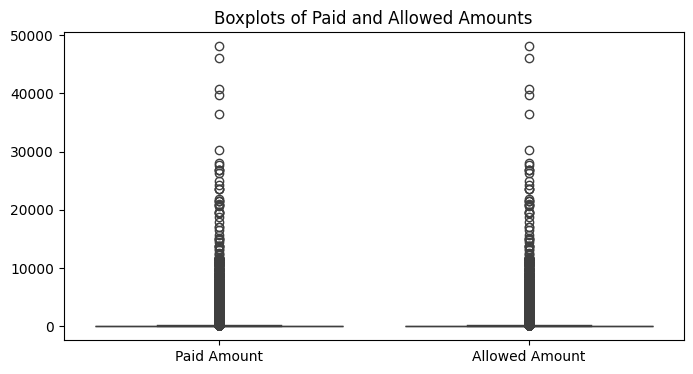

In [60]:
amount_cols = ["Paid Amount", "Allowed Amount"]

# Boxplots (raw scale)
plt.figure(figsize=(8, 4))
sns.boxplot(data=claims_clean[amount_cols])
plt.title("Boxplots of Paid and Allowed Amounts")
plt.show()

> extremely right skewed as expected

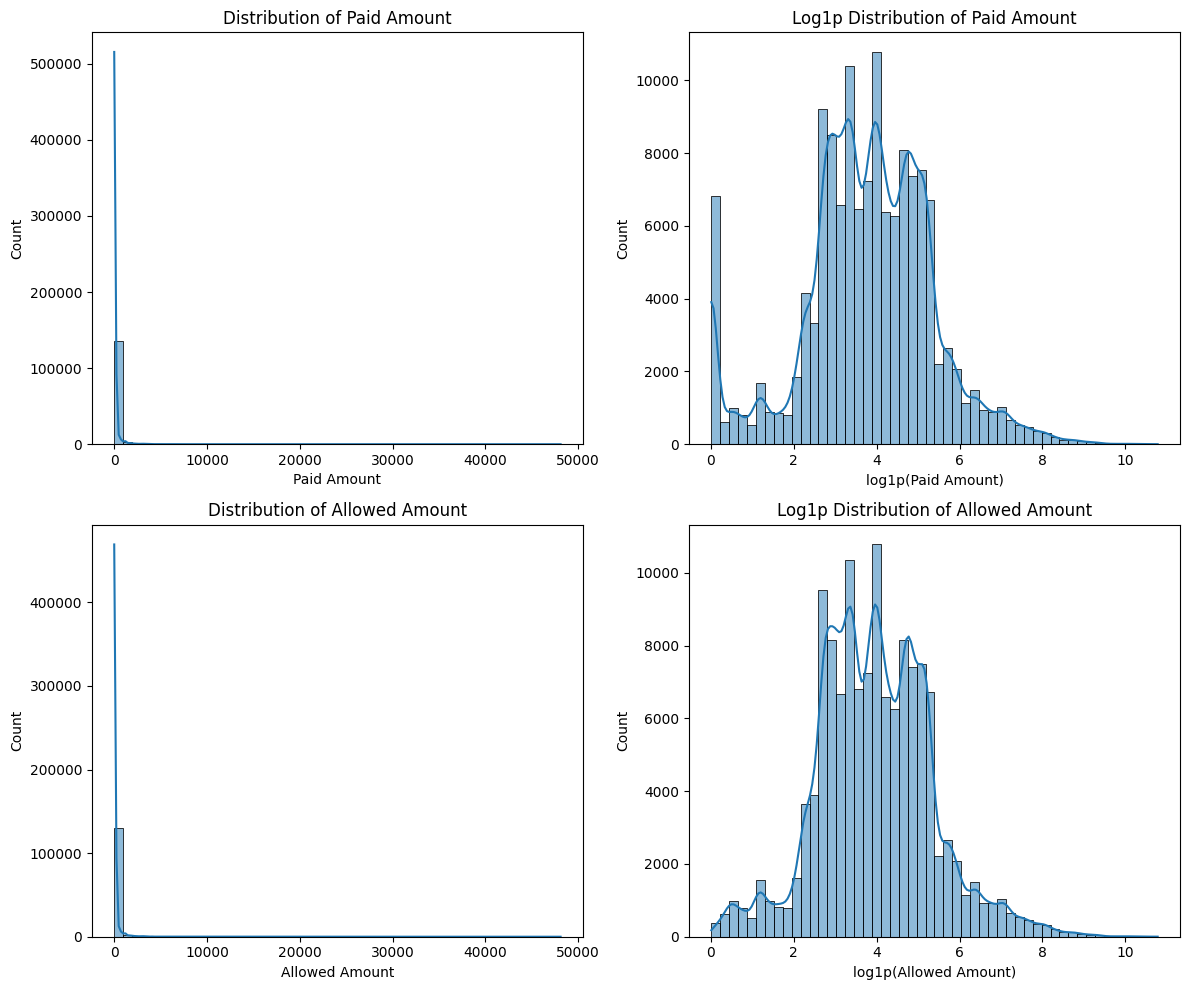

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original, paid
ax1 = axes[0, 0]
sns.histplot(claims_clean[amount_cols[0]], kde=True, bins=50, ax=ax1)
ax1.set_title(f"Distribution of {amount_cols[0]}")
ax1.set_xlabel(amount_cols[0])

# log1p, paid
ax2 = axes[0, 1]
positive_paid = claims_clean[amount_cols[0]][claims_clean[amount_cols[0]] > 0]
sns.histplot(np.log1p(positive_paid), bins=50, kde=True, ax=ax2)
ax2.set_title(f"Log1p Distribution of {amount_cols[0]}")
ax2.set_xlabel(f"log1p({amount_cols[0]})")

# Original, allowed
ax3 = axes[1, 0]
sns.histplot(claims_clean[amount_cols[1]], kde=True, bins=50, ax=ax3)
ax3.set_title(f"Distribution of {amount_cols[1]}")
ax3.set_xlabel(amount_cols[1])

# log1p, allowed
ax4 = axes[1, 1]
positive_allowed = claims_clean[amount_cols[1]][claims_clean[amount_cols[1]] > 0]
sns.histplot(np.log1p(positive_allowed), bins=50, kde=True, ax=ax4)
ax4.set_title(f"Log1p Distribution of {amount_cols[1]}")
ax4.set_xlabel(f"log1p({amount_cols[1]})")

plt.tight_layout()
plt.show()

> for plot observation:
> In the raw scale (left column), both Paid Amount and Allowed Amount are extremely right‑skewed: most claims are small, but there is a long tail of very expensive claims up to around 50k.
> In the log1p scale (right column), those long tails are compressed, and the distributions look much more bell‑ish / multi‑modal, which is exactly what log transforms are meant to do for cost data.
> In plot 2, we see a peak at x=0. We can interpret it as a categorical distribution (pay and no-pay) superposited over a numerical normal distribution (within pay, there is a rough bell-shaped distribution of the amount after log transformation). There should not be placeholder or capping.

> for conclusion:
> Very large claims are real but rare, similar to what you saw with risk scores.
> we should treat them as important high-cost claims, not as errors to automatically drop; instead, use the log1p version when needed for modeling.

In [63]:
outlier_flags = {}

for col in amount_cols:
    q1 = claims_clean[col].quantile(0.25)
    q3 = claims_clean[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr

    outlier_mask = claims_clean[col] > upper
    outlier_flags[col] = outlier_mask

    print(f"\n{col}:")
    print(" Q1:", q1, " Q3:", q3, " IQR:", iqr)
    print(" Upper fence (Q3 + 1.5*IQR):", upper)
    print(" Number of high outliers:", outlier_mask.sum())

    # Peek at a few extreme rows
    display(claims_clean.loc[outlier_mask, [col, "Member ID", "Claim Number",
                                            "Procedure Grouper Desc",
                                            "Diagnosis Grouper 1 Desc"]].head(10))


Paid Amount:
 Q1: 17.38  Q3: 121.2  IQR: 103.82000000000001
 Upper fence (Q3 + 1.5*IQR): 276.93
 Number of high outliers: 13069


,Paid Amount,Member ID,Claim Number,Procedure Grouper Desc,Diagnosis Grouper 1 Desc
22,2532.00,1,H20024218309973290000000,Inpatient Days,Liver Diseases
23,2429.90,1,H20015218304303010000000,Ambulance,Constitutional Symptoms
24,469.05,1,H20015218304303010000000,Emergency Room,Constitutional Symptoms
28,299.61,1,H19287218246158250000000,Laboratory,"Cancers, Other"
34,324.82,1,H19283218244119330000000,Anesthesia,Sleep Apnea
35,291.02,1,H19289218247709780000000,Surgery,"Cancers, Other"
42,341.67,1,H20007218298913290000000,Inpatient Hospital Care,Abdominal Disorders
50,674.53,1,H19343218281891900000000,Emergency Room,Constitutional Symptoms
52,771.46,1,H19324218270523690000000,Drugs,Liver Diseases
55,1794.78,1,H20035218316671880000000,Hospice,"Cancers, Other"



Allowed Amount:
 Q1: 18.86  Q3: 125.38  IQR: 106.52
 Upper fence (Q3 + 1.5*IQR): 285.15999999999997
 Number of high outliers: 12798


,Allowed Amount,Member ID,Claim Number,Procedure Grouper Desc,Diagnosis Grouper 1 Desc
22,2532.00,1,H20024218309973290000000,Inpatient Days,Liver Diseases
23,2429.90,1,H20015218304303010000000,Ambulance,Constitutional Symptoms
24,469.05,1,H20015218304303010000000,Emergency Room,Constitutional Symptoms
28,299.61,1,H19287218246158250000000,Laboratory,"Cancers, Other"
34,324.82,1,H19283218244119330000000,Anesthesia,Sleep Apnea
35,291.02,1,H19289218247709780000000,Surgery,"Cancers, Other"
42,341.67,1,H20007218298913290000000,Inpatient Hospital Care,Abdominal Disorders
50,674.53,1,H19343218281891900000000,Emergency Room,Constitutional Symptoms
52,771.46,1,H19324218270523690000000,Drugs,Liver Diseases
55,1794.78,1,H20035218316671880000000,Hospice,"Cancers, Other"


> the risk scores in the survey data are outputs of a risk adjustment model, not raw measurements. Their heavy right tail is a feature, not a bug: a few members are high risk by design.
> different from the risk scores, we used IQR to detect potential outliers to answer the main question was: “Are these extreme scores plausible, or do they look like errors?”
> the histograms and boxplots already showed a long but smooth tail—no obvious impossible values or weird spikes—so a formal IQR outlier count would mostly say “yes, the top few percent are high” without changing decisions.

### 2.4 Save clean dataset

In [ ]:
claims_clean.to_csv('data/member_claims_clean.csv', index=False)

### 2.5 Quick categorical EDA

In [66]:
cat_cols = [
    "Place of Service Description",
    "Speciality",
    "Provider Specialty",
    "Procedure Grouper Desc",
    "Procedure Sub-Grouper Desc",
    "Diagnosis Grouper 1 Desc",
    "Vendor Name"
]

for col in cat_cols:
    print(f"\n=== {col} ===")
    print("value counts:", claims_clean[col].value_counts())


=== Place of Service Description ===
value counts: Place of Service Description
Office                                                70965
Outpatient Hospital                                   53233
Inpatient Hospital                                     6632
Home                                                   4251
Independent Laboratory                                 2366
Telehealth                                             1731
Emergency Room - Hospital                              1560
End-Stage Renal Disease Treatment Facility              707
Mobile Unit                                             658
Ambulatory Surgical Center                              586
Rural Health Clinic                                     450
Other Place of Service                                  258
Skilled Nursing Facility                                248
Inpatient Psychiatric Facility                          177
Ambulance - Land                                        174
Urgent Care Facilit

### 2.6 Aggregation

In [68]:
member_agg = claims_clean.groupby("Member ID").agg(
    total_paid=("Paid Amount", "sum"),
    total_allowed=("Allowed Amount", "sum"),
    n_claims=("Claim Number", "nunique"),
    n_lines=("Claim Number", "size"),
).reset_index()
member_agg.describe()

,Member ID,total_paid,total_allowed,n_claims,n_lines
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,2040.348857,6513.438740,6539.214980,17.673429,41.213429
std,1192.644962,21104.004313,21153.699569,26.054923,75.182095
min,0.000000,0.000000,0.000000,1.000000,1.000000
25%,1014.750000,469.770000,474.530000,5.000000,9.000000
50%,2036.500000,1534.090000,1540.435000,11.000000,22.000000
75%,3047.250000,4695.105000,4705.247500,23.000000,49.000000
max,4779.000000,466530.420000,469136.250000,1021.000000,2496.000000


In [69]:
member_agg.head()

,Member ID,total_paid,total_allowed,n_claims,n_lines
0,0,466530.42,469136.25,1021,2496
1,1,53760.79,53760.79,65,207
2,2,1242.26,1242.26,13,16
3,3,880.41,880.40,19,28
4,4,635.46,635.46,4,9


In [70]:
member_agg.to_csv("data/member_agg.csv", index=False)

## 3. Join and feature engineering

- **Healthcare provider** cares about care delivery and getting paid.
    - Clinical and operational questions
        - Which diagnoses and procedures are most common in my population?
        - Are high‑risk patients (by risk score or chronic conditions) getting enough appropriate care (e.g., follow‑up visits, chronic disease management)?
        - Are readmissions or ED visits high for certain diagnosis groups or providers?
    - Revenue cycle and efficiency
        - How often are claims denied or paid $0?
        - How long does it take from service date to paid date?
        - Which payer or place of service patterns lead to write‑offs or lower margins?
    - Patient experience
        - Are patients who see certain specialties or in certain settings (e.g., ER vs office) reporting worse experiences in the survey?
- **Insurance** cares about the primary focus is risk, cost, and network performance.
    - Cost and utilization
        - Which members are high‑cost (from member_agg: total paid, high_paid_flag)?      
        - How do costs vary by place of service or procedure group (e.g., are some providers or facilities outliers)?     
    - Risk adjustment and population health     
        - How do prospective/concurrent risk scores relate to actual spending and utilization?   
        - Which chronic-condition combinations drive high claims and might need care management programs?
    - Network and contracting
        - Which providers deliver efficient care (good outcomes / satisfaction at reasonable cost) vs those with high cost and poor outcomes?
- **patient** cares about experience, access, and financial impact.
    - Experience & access
        - Can they get timely appointments, coordinated care, and clear communication?
        - Are chronic conditions managed across multiple providers without them “falling through the cracks”?
    - Financial burden
        - How much are they paying out‑of‑pocket versus what the plan pays (related to allowed vs paid, but from their wallet perspective)?
        - Are billing and explanation of benefits understandable and error‑free?
    - Trust and outcomes
        - Do they feel listened to, respected, and safe?
        - Are their conditions improving or at least being managed well over time?

Based on my understanding of Premise Health, I'd want to explore more on
- Professional service quality: predictive care and diagnose etc.
- Business: revenue, efficiency, cost utilization

Health service quality / clinical track

Use: risk scores, chronic condition flags, diagnosis / procedure groupers, utilization patterns (ED vs office, inpatient, telehealth), plus the survey text about experience.

Predictive ideas:

High-risk members likely to have poor control (e.g., lots of high-cost claims, many chronic conditions, repeated ER visits).

Members likely to report negative experiences or unmet needs given their risk and claim patterns.

Agentic AI angle:

An agent that monitors members’ claims and survey signals, then flags those needing proactive outreach or chronic care management, or drafts care-coordination tasks.

Business / revenue & efficiency track

Use: paid vs allowed amounts, place of service, procedure groups, provider specialty, timing (service vs paid date), high-cost claim flags, plus member-level aggregates.

Predictive ideas:

Members or service patterns that will be high-cost in the next period.

Claims at high risk of denial or $0 payment (zero-paid lines, certain providers, procedures, or places of service).

Agentic AI angle:

An agent that scans new claims, predicts denial risk or cost impact, suggests coding checks, or routes high-risk cases for human review to protect margin and cash flow.

## 3.1 Load cleaned and aggregated datasets, join on Member ID

Strategy:
- outer join survey and member_claim_agg to have complete dataset
    - obverse missing value patters for people who might be snooped later with inner join or column with NaN
        - Completely healthy, no-claim individuals.
        - Non-responders, who might systematically differ (e.g., more dissatisfied or more marginalized).
- Inner Join later with no NaN
    - we might snoop some members. But that is the scope I set for my study problem statement.
        - perfect healthy people does not influence my disease related study or my business-focused study. They probably don't need much service from the organization, but they contribute to the business
        - Non-responders might not be sick enough to have to receive serviced and or dissatisfied by the service, which can be covered by topics like how to improve client satisfaction or so.
    - there might be various reasons behind those snooped people being snooped. Those can be covered by other study topics for future work
    - This does introduce bias to the modeling and we need to keep that in mind

#### 3.1.1 Outer Join first and small EDA for patterns

In [76]:
survey_clean = pd.read_csv("data/survey_clean.csv")
member_agg = pd.read_csv("data/member_claim_agg.csv")

# Outer join on Member ID
outer_df = survey_clean.merge(member_agg, on="Member ID", how="outer", indicator=True)

outer_df["_merge"].value_counts()

_merge
both          3499
left_only     1284
right_only       1
Name: count, dtype: int64

> This is exactly what I want to see. 
> - left_only: members only in survey (no claims in your period).
>       - these people are probably completely healthy and do not need much service but contribute to business
>       - these people are not sick enough and not want to take the service. They don't use the service or impact the cost but they contribute to the business
> - right_only: members only in claims (no survey).
>       - this group impacts our business scope. However, since there if only 1 person, we could ignore for this study.
> - both: members with both survey and claims (what an inner join would keep).
>       - these people will be studied

In [80]:
# Create a segment label for readability
outer_df["member_segment"] = outer_df["_merge"].map({
    "left_only": "survey_only",
    "right_only": "claims_only",
    "both": "both"
})

print(outer_df["member_segment"].value_counts())

# Compare age and risk scores where available
summary_by_segment = outer_df.groupby("member_segment").agg(
    n_members=("Member ID", "nunique"),
    avg_age=("Age", "mean"),
    avg_prospective_risk=("Prospective Risk", "mean"),
    avg_concurrent_risk=("Concurrent Risk", "mean"),
    avg_chronic_count=("# of Chronic Conditions", "mean"),
    avg_total_paid=("total_paid", "mean"),
    avg_total_allowed=("total_allowed", "mean")
).reset_index()

print(summary_by_segment)

member_segment
both           3499
survey_only    1284
claims_only       1
Name: count, dtype: int64
  member_segment  n_members    avg_age  avg_prospective_risk  \
0    survey_only       1284  47.963396              0.470136   
1    claims_only          1        NaN                   NaN   
2           both       3499  55.110603              1.710219   

   avg_concurrent_risk  avg_chronic_count  avg_total_paid  avg_total_allowed  
0             0.284638           0.528816             NaN                NaN  
1                  NaN                NaN   466530.420000      469136.250000  
2             1.730505           1.966848     6381.967754        6407.006625  


> the simple stats confirms our assumption.
> - compared to both, survey only group generally younger with much lower prospective risk and concurrent risk scores with much less chronic count.
> - claim only group has no information filled which cannot be used for study anyway. However, the average total paid amount is dramatically higher. This person might be really sick or deceased to fill the survey. As this is one of those really marginal cases, we can cover that in other studies.

#### 3.1.2 Inner Join for my study only

In [ ]:
survey_clean = pd.read_csv("data/survey_clean.csv")
member_agg = pd.read_csv("data/member_claim_agg.csv")
print("Survey shape:", survey_clean.shape)
print("Member agg shape:", member_agg.shape)

# outer join: all members in survey, with claims data where available
member_survey_outer = survey_clean.merge(member_agg, on="Member ID", how="outer")


# Inner join: only members present in both
member_df = survey_clean.merge(member_agg, on="Member ID", how="inner")

print("Joined shape:", member_df.shape)
print(member_df.info())

Survey shape: (4783, 22)
Member agg shape: (3500, 5)
Joined shape: (3499, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3499 entries, 0 to 3498
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Member ID                    3499 non-null   int64  
 1   Age                          3499 non-null   int64  
 2   Member Gender                3499 non-null   object 
 3   Prospective Risk             3468 non-null   float64
 4   Concurrent Risk              3468 non-null   float64
 5   # of Chronic Conditions      3499 non-null   int64  
 6   ADHD                         3499 non-null   int64  
 7   Asthma                       3499 non-null   int64  
 8   Blood Disorders              3499 non-null   int64  
 9   Cancer                       3499 non-null   int64  
 10  Chronic Pain                 3499 non-null   int64  
 11  Congestive Heart Failure     3499 non-null   int64  
 12

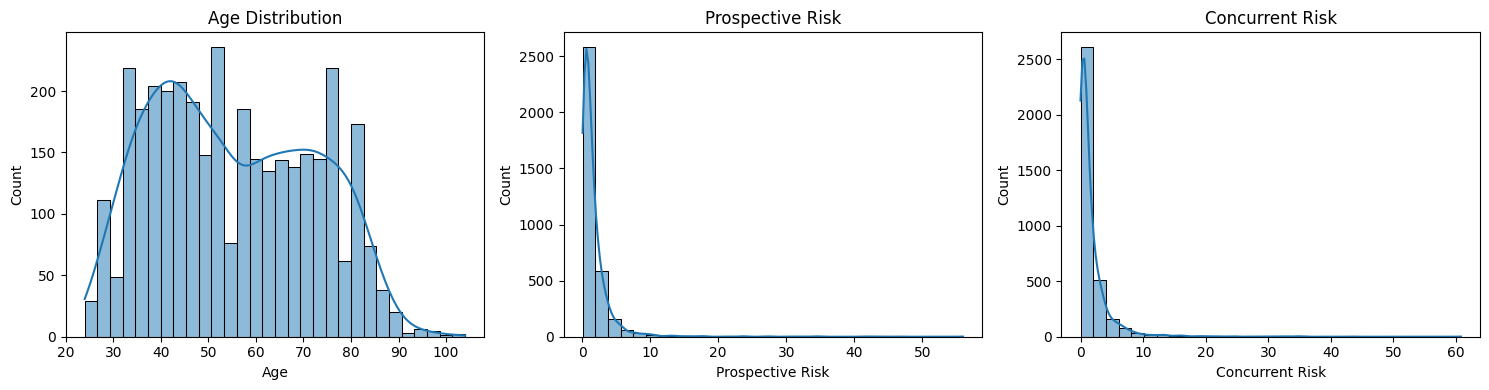

In [81]:
# 1) Age and risk distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(member_df["Age"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(member_df["Prospective Risk"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Prospective Risk")

sns.histplot(member_df["Concurrent Risk"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Concurrent Risk")

plt.tight_layout()
plt.show()

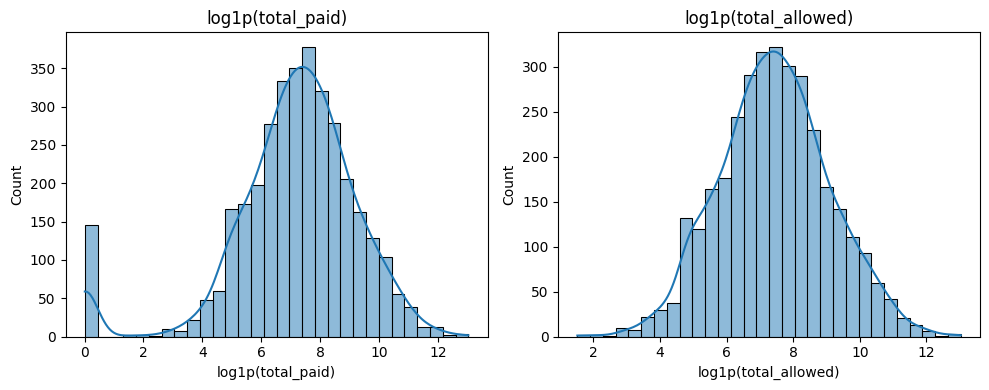

In [83]:
# 2) Total paid/allowed (log1p) to see cost spread
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for col in ["total_paid", "total_allowed"]:
    positive = member_df[col][member_df[col] > 0]
    sns.histplot(np.log1p(positive), bins=30, kde=True, ax=axes[0 if col == "total_paid" else 1])
    axes[0 if col == "total_paid" else 1].set_title(f"log1p({col})")
    axes[0 if col == "total_paid" else 1].set_xlabel(f"log1p({col})")
plt.tight_layout()
plt.show()

In [84]:
# 3) Simple “balance” checks for some natural splits

# Gender
print("Gender distribution:")
print(member_df["Member Gender"].value_counts(normalize=True))

# Any chronic condition vs none
member_df["any_chronic"] = (member_df["# of Chronic Conditions"] > 0).astype(int)
print("\nAny chronic condition (0/1) distribution:")
print(member_df["any_chronic"].value_counts(normalize=True))

# High-risk vs not (top 10% by prospective risk)
risk_threshold = member_df["Prospective Risk"].quantile(0.9)
member_df["high_risk_flag"] = (member_df["Prospective Risk"] >= risk_threshold).astype(int)
print("\nHigh-risk flag (0/1) distribution:")
print(member_df["high_risk_flag"].value_counts(normalize=True))

Gender distribution:
Member Gender
M    0.571306
F    0.428694
Name: proportion, dtype: float64

Any chronic condition (0/1) distribution:
any_chronic
1    0.690197
0    0.309803
Name: proportion, dtype: float64

High-risk flag (0/1) distribution:
high_risk_flag
0    0.900829
1    0.099171
Name: proportion, dtype: float64


> Observation:
> Gender: about 57% M, 43% F – not perfectly 50/50, but not extremely skewed either.
> Any chronic condition: about 69% have at least one chronic condition, 31% have none – this makes sense in a cohort of people who both have claims and responded to a survey; they’re more likely to be active users of care.
> High-risk flag: by construction, about 10% high-risk and 90% not, since you used the 90th percentile as the cutoff; this is a typical way to define “top risk decile.
> Conclusion:
> Gender and any_chronic are reasonably balanced that doesn’t need to resample on those.
> If we later choose a top 10% label as the prediction target (e.g., high-cost or high-risk), we will be working with a moderately imbalanced classification problem (roughly 1:9). That’s common and can be handled with techniques like class weights, appropriate metrics (ROC AUC, PR AUC), or mild resampling rather than forcing balance.

#### 3.1.3 Feature engineering for Business / cost target

- purpose: identifying high-cost members and the drivers of spend
- strategy:
    - Define a clear high-cost label with existing total_paid column at the member level. use common choices in the literature are top 5–10% of spenders, or an absolute dollar cutoff (e.g., members above some high dollar threshold).
    - Compute the 90th percentile of total_paid. Create high_cost_flag = 1 if total_paid ≥ that percentile, else 0.
Targeting care management or outreach to likely high-cost members.
Budgeting and risk assessment for upcoming plan years.

In [85]:
# Choose a percentile threshold, e.g., 90th
cost_threshold = member_df["total_paid"].quantile(0.9)

member_df["high_cost_flag"] = (member_df["total_paid"] >= cost_threshold).astype(int)

print("High-cost threshold (total_paid):", cost_threshold)
print(member_df["high_cost_flag"].value_counts(normalize=True))

High-cost threshold (total_paid): 14391.780000000006
high_cost_flag
0    0.899971
1    0.100029
Name: proportion, dtype: float64


In [88]:
claims.columns

Index(['Member ID', 'Claim Number', 'Service Date', 'Paid Date',
       'Place of Service Description', 'Speciality', 'Provider Specialty',
       'Paid Amount', 'Allowed Amount', 'Primary Diagnosis Desc',
       'Procedure Description', 'CPT4', 'Vendor Name', 'Procedure',
       'Procedure Grouper Desc', 'Procedure Sub-Grouper Desc',
       'Diagnosis Grouper 1 Desc', 'Diagnosis Super-Grouper 1 Desc'],
      dtype='object')

From here, I'd like to further study the Utilization: counts of claims, inpatient vs outpatient visits, distinct providers, etc. to help with better budget resource allocation. I chose n_inpatient_claims and n_outpatient_claims as my main feature as, based on my understanding of Premise Health, outpatience, community healthcare services, and entry level clinic is the focus. Inpatience would take way too much resources yet does not align with the company's focus and stength. Help with understanding this will help Premise Health to focus on the strength to help more people, be more cost-efficient, and profitable.

In [ ]:
# Check unique values and counts
print(claims['Place of Service Description'].value_counts())
print(claims['Provider Specialty'].value_counts())

Place of Service - top 10:
Place of Service Description
Office                                                70965
Outpatient Hospital                                   53233
Inpatient Hospital                                     6632
Home                                                   4251
Independent Laboratory                                 2366
Telehealth                                             1731
Emergency Room - Hospital                              1560
End-Stage Renal Disease Treatment Facility              707
Mobile Unit                                             658
Ambulatory Surgical Center                              586
Rural Health Clinic                                     450
Other Place of Service                                  258
Skilled Nursing Facility                                248
Inpatient Psychiatric Facility                          177
Ambulance - Land                                        174
Urgent Care Facility                        

In [91]:
# Step 1: Define place of service categories
primary_outpatient = ['Office', 'Telehealth', 'Urgent Care Facility', 
                      'Walk-in Retail Health Clinic', 'Rural Health Clinic']
hospital_outpatient = ['Outpatient Hospital', 'Emergency Room - Hospital']
inpatient = ['Inpatient Hospital', 'Inpatient Psychiatric Facility', 
             'Skilled Nursing Facility']

# Step 2: Create category flags in claims dataframe
claims_clean['is_primary_outpatient'] = claims_clean['Place of Service Description'].isin(primary_outpatient).astype(int)
claims_clean['is_hospital_outpatient'] = claims_clean['Place of Service Description'].isin(hospital_outpatient).astype(int)
claims_clean['is_inpatient'] = claims_clean['Place of Service Description'].isin(inpatient).astype(int)

# Step 3: Aggregate by Member ID
utilization = claims_clean.groupby('Member ID').agg(
    n_total_claims=('Member ID', 'size'),
    n_primary_outpatient=('is_primary_outpatient', 'sum'),
    n_hospital_outpatient=('is_hospital_outpatient', 'sum'),
    n_inpatient=('is_inpatient', 'sum')
).reset_index()

# Step 4: Create percentage feature
utilization['pct_primary_outpatient'] = (
    utilization['n_primary_outpatient'] / utilization['n_total_claims']
).fillna(0)

# Step 5: Merge into member_df
member_df = member_df.merge(utilization, on='Member ID', how='left')

# Step 6: Check results
print(member_df[['Member ID', 'n_total_claims', 'n_primary_outpatient', 
                  'n_hospital_outpatient', 'n_inpatient', 'pct_primary_outpatient']].head())

   Member ID  n_total_claims  n_primary_outpatient  n_hospital_outpatient  \
0          1             207                    26                     98   
1          2              16                    13                      3   
2          3              28                    16                      0   
3          4               9                     6                      3   
4          5               2                     2                      0   

   n_inpatient  pct_primary_outpatient  
0           80                0.125604  
1            0                0.812500  
2            0                0.571429  
3            0                0.666667  
4            0                1.000000  


In [92]:
# Flag: high chronic conditions but low primary care use
member_df['chronic_low_primary'] = (
    (member_df['any_chronic'] == 1) & 
    (member_df['pct_primary_outpatient'] < member_df['pct_primary_outpatient'].median())
).astype(int)

In [94]:
member_df.columns

Index(['Member ID', 'Age', 'Member Gender', 'Prospective Risk',
       'Concurrent Risk', '# of Chronic Conditions', 'ADHD', 'Asthma',
       'Blood Disorders', 'Cancer', 'Chronic Pain', 'Congestive Heart Failure',
       'Chronic Respiratory Failure', 'Depression', 'Diabetes', 'ESRD',
       'Eating Disorders', 'HIV/AIDS', 'Hyperlipidemia', 'Hypertension',
       'Lower Back Pain', 'Patient Survey Response', 'total_paid',
       'total_allowed', 'n_claims', 'n_lines', 'any_chronic', 'high_risk_flag',
       'high_cost_flag', 'n_total_claims', 'n_primary_outpatient',
       'n_hospital_outpatient', 'n_inpatient', 'pct_primary_outpatient',
       'chronic_low_primary'],
      dtype='object')

In [98]:
claims_clean.columns

Index(['Member ID', 'Claim Number', 'Service Date', 'Paid Date',
       'Place of Service Description', 'Speciality', 'Provider Specialty',
       'Paid Amount', 'Allowed Amount', 'Primary Diagnosis Desc',
       'Procedure Description', 'CPT4', 'Vendor Name', 'Procedure',
       'Procedure Grouper Desc', 'Procedure Sub-Grouper Desc',
       'Diagnosis Grouper 1 Desc', 'Diagnosis Super-Grouper 1 Desc',
       'is_primary_outpatient', 'is_hospital_outpatient', 'is_inpatient'],
      dtype='object')

## 4. Modeling and analysis